<a href="https://colab.research.google.com/github/dosawaru/cse_572_project/blob/main/CSE572_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import zipfile
import os

# Upload ZIP
print("dataset.zip")
uploaded = files.upload()

zip_path = list(uploaded.keys())[0]

# Extract ZIP
extract_dir = "dataset"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:", os.listdir(extract_dir))

Upload archive (7).zip


Saving archive (7).zip to archive (7) (1).zip
Extracted files: ['CEAS_08.csv', 'Enron.csv', 'Ling.csv', 'Nigerian_Fraud.csv', 'Nazario.csv', 'SpamAssasin.csv', 'phishing_email.csv']


In [ ]:
import pandas as pd

folder = "dataset"
csv_files = [f for f in os.listdir(folder) if f.endswith(".csv")]

dfs = []

for file in csv_files:
    df = pd.read_csv(os.path.join(folder, file), encoding="latin1", on_bad_lines="skip")
    df["source"] = file      # track origin
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print("Combined Shape:", data.shape)
data.head()

Combined Shape: (164972, 9)


,sender,receiver,date,subject,body,label,urls,source,text_combined
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1.0,CEAS_08.csv,NaN
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1.0,CEAS_08.csv,NaN
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1.0,CEAS_08.csv,NaN
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1.0,CEAS_08.csv,NaN
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1.0,CEAS_08.csv,NaN


In [ ]:
# Identify text-like columns
text_cols = [c for c in data.columns
             if "text" in c.lower() or "body" in c.lower() or
                "email" in c.lower() or "message" in c.lower()]

print("Detected text column:", text_cols)

# Identify label-like columns
label_cols = [c for c in data.columns
              if "label" in c.lower() or "spam" in c.lower() or
                 "phish" in c.lower() or "class" in c.lower()]

print("Detected label column:", label_cols)

TEXT_COL = text_cols[0]
LABEL_COL = label_cols[0]

data = data[[TEXT_COL, LABEL_COL]].dropna()
data.columns = ["text", "label"]
data.head()

Detected text column: ['body', 'text_combined']
Detected label column: ['label']


,text,label
0,"Buck up, your troubles caused by small dimensi...",1
1,\nUpgrade your sex and pleasures with these te...,1
2,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1
3,Would anyone object to removing .so from this ...,0
4,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1


In [ ]:
data.isnull().sum()

,0
text,0
label,0


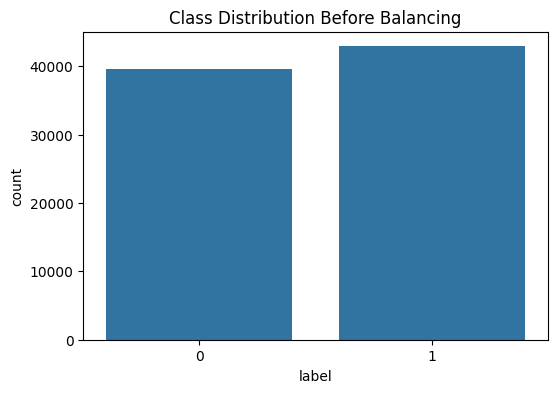

,count
label,
1,42890
0,39595


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=data["label"])
plt.title("Class Distribution Before Balancing")
plt.show()

data["label"].value_counts()

In [ ]:
data["text"] = data["text"].astype(str).str.lower()
data["text"] = data["text"].str.replace(r"<.*?>", "", regex=True)
data["text"] = data["text"].str.replace(r"\s+", " ", regex=True)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
X = tfidf.fit_transform(data["text"])
y = data["label"]

Before Balancing:
 label
1    42890
0    39595
Name: count, dtype: int64

After Balancing:
 label
1    42890
0    42890
Name: count, dtype: int64


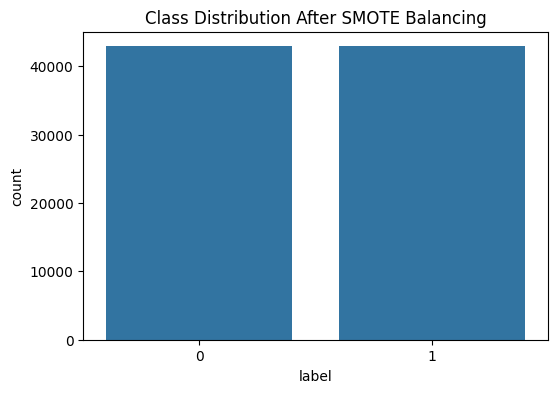

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_balanced, y_balanced = sm.fit_resample(X, y)

print("Before Balancing:\n", y.value_counts())
print("\nAfter Balancing:\n", pd.Series(y_balanced).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_balanced)
plt.title("Class Distribution After SMOTE Balancing")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

# List contents of your Google Drive (optional, adjust path as needed)
print(os.listdir('/content/drive/MyDrive'))

After mounting, you can specify the path to your data file in Google Drive, for example: `/content/drive/MyDrive/path/to/your_file.csv` to load it into a pandas DataFrame or similar.

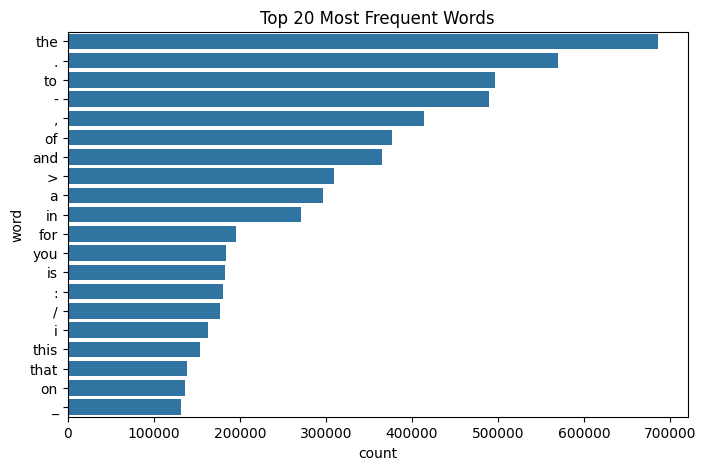

In [ ]:
from collections import Counter

words = " ".join(data["text"]).split()
word_freq = Counter(words).most_common(20)

df_freq = pd.DataFrame(word_freq, columns=["word", "count"])

plt.figure(figsize=(8,5))
sns.barplot(x="count", y="word", data=df_freq)
plt.title("Top 20 Most Frequent Words")
plt.show()